In [103]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.metrics import confusion_matrix, precision_recall_curve

from src.reassemble_datasets import reassemble_predictors_datasets
from src.run_windowed_prediction import run_windowed_predict

In [79]:
drop_inst_ids_list = [246]
flds_selection = [
    'id_time', 
    'n_flows', 'n_packets', 'n_bytes',
    'std_n_dest_ip', 'std_n_dest_ports',
    'tcp_udp_ratio_packets', 'dir_ratio_packets',
    'avg_duration', 'avg_ttl'
]
proj_root = os.environ['PYTHONPATH']

In [80]:
X_unscaled, X_scaled, X_pca, X_svd, flds_list = reassemble_predictors_datasets(drop_inst_ids_list, flds_selection)

In [81]:
[ el.shape for el in [X_unscaled, X_scaled, X_pca, X_svd] ]

[(280, 2540), (280, 2540), (280, 260), (280, 260)]

In [82]:
y_full = pd.read_csv(os.path.join(proj_root, 'preprocessed_datasets', 'inst_217_marked_target.csv')).is_overloaded.values

In [83]:
metrics_list = []
model_list = []
counter = 0

for X in [X_unscaled, X_scaled, X_pca, X_svd]:
    metrics, model = run_windowed_predict(X, y_full)
    metrics_list.append(metrics)
    model_list.append(model)
    counter += 1
    print(counter, 'runs passed - please wait...')

print('FYI: All runs completed.')

1 runs passed - please wait...
2 runs passed - please wait...
3 runs passed - please wait...
4 runs passed - please wait...
FYI: All runs completed.


In [84]:
np.array(metrics_list)

array([[0.82      , 0.81746032, 0.72727273, 0.57142857, 0.64      ],
       [0.82      , 0.81746032, 0.72727273, 0.57142857, 0.64      ],
       [0.72      , 0.67857143, 0.5       , 0.07142857, 0.125     ],
       [0.72      , 0.6547619 , 0.5       , 0.21428571, 0.3       ]])

In [85]:
metrics_list_2 = []
model_list_2 = []
counter = 0

for X in [X_unscaled, X_scaled, X_pca, X_svd]:
    metrics, model = run_windowed_predict(X, y_full, post_window=14)
    metrics_list_2.append(metrics)
    model_list_2.append(model)
    counter += 1
    print(counter, 'runs passed - please wait...')

print('FYI: All runs completed.')

1 runs passed - please wait...
2 runs passed - please wait...
3 runs passed - please wait...
4 runs passed - please wait...
FYI: All runs completed.


In [86]:
np.array(metrics_list_2)

array([[0.64      , 0.70634921, 0.41666667, 0.71428571, 0.52631579],
       [0.64      , 0.70634921, 0.41666667, 0.71428571, 0.52631579],
       [0.74      , 0.78769841, 0.57142857, 0.28571429, 0.38095238],
       [0.7       , 0.73214286, 0.46153846, 0.42857143, 0.44444444]])

In [87]:
metrics_list_3 = []
model_list_3 = []
counter = 0

for X in [X_unscaled, X_scaled, X_pca, X_svd]:
    metrics, model = run_windowed_predict(X, y_full, post_window=3)
    metrics_list_3.append(metrics)
    model_list_3.append(model)
    counter += 1
    print(counter, 'runs passed - please wait...')

print('FYI: All runs completed.')

1 runs passed - please wait...
2 runs passed - please wait...
3 runs passed - please wait...
4 runs passed - please wait...
FYI: All runs completed.


In [88]:
np.array(metrics_list_3)

array([[0.6       , 0.43055556, 0.125     , 0.07142857, 0.09090909],
       [0.6       , 0.42857143, 0.125     , 0.07142857, 0.09090909],
       [0.7       , 0.5297619 , 0.33333333, 0.07142857, 0.11764706],
       [0.72      , 0.64880952, 0.5       , 0.07142857, 0.125     ]])

In [89]:
total_view = pd.DataFrame()

view_tmp =pd.DataFrame(
    index=['unscaled', 'scaled', 'pca', 'svd'],
    columns=['accuracy', 'roc-auc', 'precision', 'recall', 'f1'],
    data=np.array(metrics_list)
)

view_tmp = view_tmp.reset_index().rename(columns={'index': 'preprocessing'})
view_tmp['post_window'] = 7

total_view = pd.concat([total_view, view_tmp])

view_tmp =pd.DataFrame(
    index=['unscaled', 'scaled', 'pca', 'svd'],
    columns=['accuracy', 'roc-auc', 'precision', 'recall', 'f1'],
    data=np.array(metrics_list_2)
)

view_tmp = view_tmp.reset_index().rename(columns={'index': 'preprocessing'})
view_tmp['post_window'] = 14

total_view = pd.concat([total_view, view_tmp])

view_tmp =pd.DataFrame(
    index=['unscaled', 'scaled', 'pca', 'svd'],
    columns=['accuracy', 'roc-auc', 'precision', 'recall', 'f1'],
    data=np.array(metrics_list_3)
)

view_tmp = view_tmp.reset_index().rename(columns={'index': 'preprocessing'})
view_tmp['post_window'] = 3

total_view = pd.concat([total_view, view_tmp])


In [90]:
                  
total_view.set_index(['preprocessing','post_window']).sort_values('f1', ascending=False).map(lambda x: round(x, 2))

accuracy  roc-auc  precision  recall    f1
preprocessing post_window                                            
unscaled      7                0.82     0.82       0.73    0.57  0.64
scaled        7                0.82     0.82       0.73    0.57  0.64
              14               0.64     0.71       0.42    0.71  0.53
unscaled      14               0.64     0.71       0.42    0.71  0.53
svd           14               0.70     0.73       0.46    0.43  0.44
pca           14               0.74     0.79       0.57    0.29  0.38
svd           7                0.72     0.65       0.50    0.21  0.30
pca           7                0.72     0.68       0.50    0.07  0.12
svd           3                0.72     0.65       0.50    0.07  0.12
pca           3                0.70     0.53       0.33    0.07  0.12
scaled        3                0.60     0.43       0.12    0.07  0.09
unscaled      3                0.60     0.43       0.12    0.07  0.09

In [91]:
best_model = model_list[0]
best_model

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

In [92]:
post_window = 7
horizon = 1

X_wd = np.stack([
                         X_unscaled[i-post_window:i].flatten().copy() 
                         for i in range(post_window, X_unscaled.shape[0]-horizon)
                        ], axis=0)
        
y_wd = y_full[post_window + horizon : X_unscaled.shape[0]]

X_wd_train = X_wd[:-50]
X_wd_test = X_wd[-50:]

y_wd_train = y_wd[:-50]
y_wd_test = y_wd[-50:]

In [93]:
print('   на обучающих данных:')

view_tmp = pd.DataFrame({'predicted': best_model.predict(X_wd_train), 'actual': y_wd_train})

pd.DataFrame(
    columns=['pred_0', 'pred_1'],
    index=['actual_0', 'actual_1'],
    data=confusion_matrix(view_tmp['actual'], view_tmp['predicted'])
)

   на обучающих данных:


,pred_0,pred_1
actual_0,183,0
actual_1,0,39


In [94]:
print('   на тестовых данных:')

view_tmp = pd.DataFrame({'predicted': best_model.predict(X_wd_test), 'actual': y_wd_test})

pd.DataFrame(
    columns=['pred_0', 'pred_1'],
    index=['actual_0', 'actual_1'],
    data=confusion_matrix(view_tmp['actual'], view_tmp['predicted'])
)

   на тестовых данных:


,pred_0,pred_1
actual_0,33,3
actual_1,6,8


In [95]:
print('   матрица конфликтов:')

pd.DataFrame(
    columns=['pred_0', 'pred_1'],
    index=['actual_0', 'actual_1'],
    data=[
        ['TN', 'FP'],
        ['FN', 'TP']
    ]
)

   матрица конфликтов:


,pred_0,pred_1
actual_0,TN,FP
actual_1,FN,TP


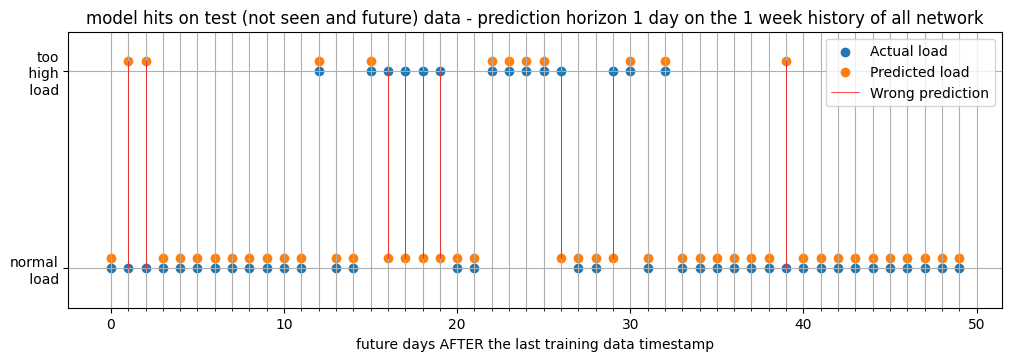

In [101]:
plt.figure(figsize=(10, 3.5), layout='constrained')
plt.scatter(view_tmp['actual'].index, view_tmp['actual'].values, label='Actual load')
plt.scatter(view_tmp['predicted'].index, view_tmp['predicted'].values+0.05, label='Predicted load')
for idx in view_tmp.index:
    if view_tmp.loc[idx, 'actual'] != view_tmp.loc[idx, 'predicted']:
        plt.plot([idx, idx], [view_tmp.loc[idx, 'actual'], view_tmp.loc[idx, 'predicted'] + 0.05], 
                 color='red', linewidth=0.5)
plt.plot([0,0], [-1,-2], color='red', linewidth=0.5, label='Wrong prediction')
plt.xticks(view_tmp['actual'].index, minor=True)
plt.yticks([0,1], labels=['normal\n load', 'too\n high\n load'])
plt.ylim(-0.2, 1.2)
plt.grid(which='both')
plt.legend()
plt.title('model hits on test (not seen and future) data - prediction horizon 1 day on the 1 week history of all network')
plt.xlabel('future days AFTER the last training data timestamp')
plt.show()

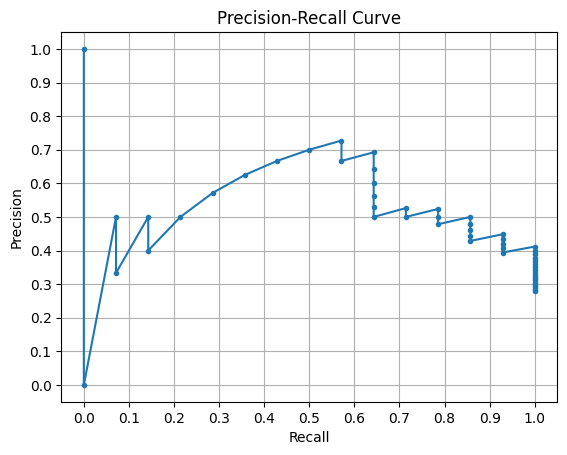

In [108]:
PR_curve = precision_recall_curve(y_wd_test, best_model.predict_proba(X_wd_test)[:, 1])

plt.plot(PR_curve[1], PR_curve[0], marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid()
plt.show()

In [109]:
metrics_list = []
model_list = []
counter = 0

for h in range(1,8):
    metrics, model = run_windowed_predict(X_unscaled, y_full, horizon=h)
    metrics_list.append(metrics)
    model_list.append(model)
    counter += 1
    print(counter, 'runs passed - please wait...')

print('FYI: All runs completed.')

1 runs passed - please wait...
2 runs passed - please wait...
3 runs passed - please wait...
4 runs passed - please wait...
5 runs passed - please wait...
6 runs passed - please wait...
7 runs passed - please wait...
FYI: All runs completed.


In [110]:
np.array(metrics_list)

array([[0.82      , 0.81746032, 0.72727273, 0.57142857, 0.64      ],
       [0.74      , 0.83928571, 0.52380952, 0.78571429, 0.62857143],
       [0.78      , 0.84126984, 0.58823529, 0.71428571, 0.64516129],
       [0.8       , 0.87698413, 0.625     , 0.71428571, 0.66666667],
       [0.7       , 0.77380952, 0.47826087, 0.78571429, 0.59459459],
       [0.66      , 0.76388889, 0.42857143, 0.64285714, 0.51428571],
       [0.64      , 0.65873016, 0.42307692, 0.78571429, 0.55      ]])

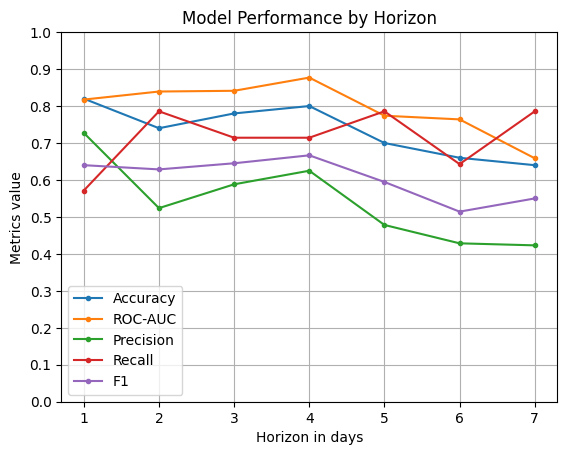

In [113]:
plt.plot(np.arange(1, 8), np.array(metrics_list)[:, 0], marker='.', label='Accuracy')
plt.plot(np.arange(1, 8), np.array(metrics_list)[:, 1], marker='.', label='ROC-AUC')
plt.plot(np.arange(1, 8), np.array(metrics_list)[:, 2], marker='.', label='Precision')
plt.plot(np.arange(1, 8), np.array(metrics_list)[:, 3], marker='.', label='Recall')
plt.plot(np.arange(1, 8), np.array(metrics_list)[:, 4], marker='.', label='F1')
plt.xlabel('Horizon in days')
plt.ylabel('Metrics value')
plt.title('Model Performance by Horizon')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend()    
plt.grid()
plt.show()